In [1]:
import tensorflow as tf
from tensorflow.contrib import layers
from tensorflow.contrib import rnn  # will probably be moved to code in TF 1.1. Keep it imported as rnn to make the rest of the code independent of this.
import datetime
import os
import time
#import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils_ii_rnn_ver_2 import IIRNNDataHandler
#from utils_ii_rnn import IIRNNDataHandler
#from test_util_ver_final_ver_len15 import Tester
#from test_util_ver_final_ver_len20 import Tester
from test_util_ver_final_ver_len200 import Tester

C:\Users\Jun\Anaconda3\envs\Jun-model\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\Jun\Anaconda3\envs\Jun-model\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\Users\Jun\Anaconda3\envs\Jun-model\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
C:\Users\Jun\Anaconda3\envs\Jun-model\lib\site-packages\tensorflow\

In [2]:
runtime = time.time()

reddit = "subreddit"
lastfm = "lastfm"
instacart = "instacart"
tmall = "tmall_6"
amazon = "amazon"
MovieLens_1M = 'MovieLens-1M'
MovieLens_20M = 'MovieLens-20M'
steam = 'steam'

dataset = MovieLens_1M #dataset
use_last_hidden_state = True

do_training = True #False
save_best = True

isExists_file = os.path.exists('./testlog')
if not isExists_file:
    os.makedirs('./testlog') 
    
log_file_name = 'ii-rnn' #change name
home = 'C:/Users/Jun/Test/Jun model/Rec/Jun-Rec (TF_1.14)'
dataset_path = home + '/datasets/'+dataset+'/4_train_test_split.pickle'
#dataset_path = home + '/datasets/'+dataset+'/4_train_test_split_sapmle.pickle'
epoch_file = './epoch_file-'+log_file_name+'-'+dataset+'.pickle'
checkpoint_file = './checkpoints/'+log_file_name+'-'+dataset+'-'
checkpoint_file_ending = '.ckpt'
date_now = datetime.datetime.fromtimestamp(time.time()).strftime('%Y-%m-%d')
log_file = './testlog/'+str(date_now)+'-testing-'+log_file_name+'.txt'

seed = 0
tf.set_random_seed(seed)

N_ITEMS      = -1
BATCHSIZE    = 100  #tmall=16 amazon=16 other=100 #意味著一次讀取多少筆資料(我猜)

if dataset == reddit:
    ST_INTERNALSIZE = 50
    LT_INTERNALSIZE = ST_INTERNALSIZE
    learning_rate = 0.001
    dropout_pkeep = 1.0
    MAX_SESSION_REPRESENTATIONS = 15
    MAX_EPOCHS = 31 #31
elif dataset == lastfm:
    ST_INTERNALSIZE = 100
    LT_INTERNALSIZE = ST_INTERNALSIZE
    learning_rate = 0.001
    dropout_pkeep = 0.8
    MAX_SESSION_REPRESENTATIONS = 15
    MAX_EPOCHS = 50 #50
elif dataset == instacart:
    ST_INTERNALSIZE = 80
    LT_INTERNALSIZE = ST_INTERNALSIZE
    learning_rate = 0.001
    dropout_pkeep = 0.8
    MAX_SESSION_REPRESENTATIONS = 15
    MAX_EPOCHS = 200 #200
elif dataset == tmall:
    ST_INTERNALSIZE = 100
    LT_INTERNALSIZE = ST_INTERNALSIZE
    learning_rate = 0.001
    dropout_pkeep = 0.8
    MAX_SESSION_REPRESENTATIONS = 15
    MAX_EPOCHS = 50
elif dataset == amazon:
    ST_INTERNALSIZE = 80
    LT_INTERNALSIZE = ST_INTERNALSIZE
    learning_rate = 0.001
    dropout_pkeep = 0.8
    MAX_SESSION_REPRESENTATIONS = 15
    MAX_EPOCHS = 100
elif dataset == MovieLens_1M:
    ST_INTERNALSIZE = 80
    LT_INTERNALSIZE = ST_INTERNALSIZE
    learning_rate = 0.01
    dropout_pkeep = 0.8
    MAX_SESSION_REPRESENTATIONS = 15
    MAX_EPOCHS = 200
elif dataset == MovieLens_20M:
    ST_INTERNALSIZE = 80
    LT_INTERNALSIZE = ST_INTERNALSIZE
    learning_rate = 0.01
    dropout_pkeep = 0.8
    MAX_SESSION_REPRESENTATIONS = 15
    MAX_EPOCHS = 200
elif dataset == steam:
    ST_INTERNALSIZE = 80
    LT_INTERNALSIZE = ST_INTERNALSIZE
    learning_rate = 0.001
    dropout_pkeep = 0.8
    MAX_SESSION_REPRESENTATIONS = 15
    MAX_EPOCHS = 200

N_LAYERS     = 1        # number of layers in the rnn
SEQLEN       = 20-1     # maximum number of actions in a session (or more precisely, how far into the future an action affects future actions. This is important for training, but when running, we can have as long sequences as we want! Just need to keep the hidden state and compute the next action)
EMBEDDING_SIZE = ST_INTERNALSIZE
TOP_K = 20

# Load training data
datahandler = IIRNNDataHandler(dataset_path, BATCHSIZE, log_file, 
        MAX_SESSION_REPRESENTATIONS, LT_INTERNALSIZE)
N_ITEMS = datahandler.get_num_items() 
N_SESSIONS = datahandler.get_num_training_sessions()

message = "------------------------------------------\n"

message += "DATASET: "+dataset+" MODEL: II-RNN"
message += "\nCONFIG: N_ITEMS="+str(N_ITEMS)+" BATCHSIZE="+str(BATCHSIZE)
message += "\nST_INTERNALSIZE="+str(ST_INTERNALSIZE)+" LT_INTERNALSIZE="+str(LT_INTERNALSIZE)
message += "\nN_LAYERS="+str(N_LAYERS)+" SEQLEN="+str(SEQLEN)+" EMBEDDING_SIZE="+str(EMBEDDING_SIZE)
message += "\nN_SESSIONS="+str(N_SESSIONS)+" SEED="+str(seed)
message += "\nMAX_SESSION_REPRESENTATIONS="+str(MAX_SESSION_REPRESENTATIONS)
message += "\nDROPOUT="+str(dropout_pkeep)+" LEARNING_RATE="+str(learning_rate)
message += ("\n\n評估測試方式:"+
            "\n如果session長度=20。訓練/測試長度本身差1位子(訓練:20/測試:19)，因此測試中會有1-19個對答案的結果。"+
            "\n#每讀取到該指定位子都會與ground truth計算評估分數，並統計從前面計數到該時間的成績(分子/分母皆會累計)。"+
            "\nex: i<=4 的結果包含統計所有session中的前5個紀錄的輸入結果。"+
            "\nex: i<=19 的結果包含統計所有session中的前20個紀錄的輸入結果。\n")
datahandler.log_config(message)
print(message)

Loading dataset
|- dataset loaded in 0.2794983386993408 s
------------------------------------------
DATASET: MovieLens-1M MODEL: II-RNN
CONFIG: N_ITEMS=3328 BATCHSIZE=100
ST_INTERNALSIZE=80 LT_INTERNALSIZE=80
N_LAYERS=1 SEQLEN=19 EMBEDDING_SIZE=80
N_SESSIONS=2096 SEED=0
MAX_SESSION_REPRESENTATIONS=15
DROPOUT=0.8 LEARNING_RATE=0.01

評估測試方式:
如果session長度=20。訓練/測試長度本身差1位子(訓練:20/測試:19)，因此測試中會有1-19個對答案的結果。
#每讀取到該指定位子都會與ground truth計算評估分數，並統計從前面計數到該時間的成績(分子/分母皆會累計)。
ex: i<=4 的結果包含統計所有session中的前5個紀錄的輸入結果。
ex: i<=19 的結果包含統計所有session中的前20個紀錄的輸入結果。



In [3]:
# 生成走勢圖
def png(epoch, value_1, value_2, value_3, value_4, value_5):
    plt.xlabel("Epoch")    
    
    if epoch == "loss_epoch":
        plt.ylabel("loss")
       
    else:
        plt.ylabel("%")
    
    fig = plt.figure(figsize=(6,4))
    fig.patch.set_facecolor('white')
    plt.rcParams['font.sans-serif'] = ['Yu Gothic']
    plt.grid(True)
    
    if epoch == "loss_epoch":
        plt.plot(df_3[epoch], df_3[value_1])
        plt.plot(df_3[epoch], df_3[value_2])
        plt.legend([value_1, value_2], loc="upper left")
        
    elif epoch == "train_epoch":
        plt.plot(df_1[epoch], df_1[value_1])
        plt.plot(df_1[epoch], df_1[value_2])
        plt.plot(df_1[epoch], df_1[value_3])
        plt.legend([value_1, value_2, value_3], loc="upper left")
        
    elif epoch == "test_epoch":  
        plt.plot(df_2[epoch], df_2[value_1])
        plt.plot(df_2[epoch], df_2[value_2])
        plt.plot(df_2[epoch], df_2[value_3])
        plt.legend([value_1, value_2, value_3], loc="upper left")
        
    plt.title(value_5)
    plt.savefig("./testlog/"+ value_4 + ".png")
    plt.clf()

In [4]:
if not do_training:
    print("\nOBS!!!! Training is turned off!\n")

In [5]:
##
## The model
##
print("Creating model")

gpu = ['/gpu:0']

# Use (CPU) RAM to hold embeddings. If >10 GB of VRAM available, you can put 
# this there instead, which should reduce runtime

with tf.device(gpu[0]):

    # Inputs
    X = tf.placeholder(tf.int32, [None, None], name='X')    # [ BATCHSIZE, SEQLEN ]
    Y_ = tf.placeholder(tf.int32, [None, None], name='Y_')  # [ BATCHSIZE, SEQLEN ]
    
    # Embeddings. W_embed = all embeddings. X_embed = retrieved embeddings 
    # from W_embed, corresponding to the items in the current batch
    W_embed = tf.Variable(tf.random_uniform([N_ITEMS, EMBEDDING_SIZE], -1.0, 1.0), name='embeddings')
    X_embed = tf.nn.embedding_lookup(W_embed, X) # [BATCHSIZE, SEQLEN, EMBEDDING_SIZE]

#with tf.device(gpu[0]):

    # Length of sesssions (not considering padding)
    seq_len = tf.placeholder(tf.int32, [None], name='seqlen')
    batchsize = tf.placeholder(tf.int32, name='batchsize')
    
    # Average of embeddings session representation
    X_sum = tf.reduce_sum(X_embed, 1)
    X_avg = tf.transpose(tf.realdiv(tf.transpose(X_sum), tf.cast(seq_len, tf.float32)))

    lr = tf.placeholder(tf.float32, name='lr')              # learning rate
    pkeep = tf.placeholder(tf.float32, name='pkeep')        # dropout parameter

    # Input to inter-session RNN layer
    X_lt = tf.placeholder(tf.float32, [None, None, LT_INTERNALSIZE], name='X_lt') #[BATCHSIZE, LT_INTERNALSIZE]
    seq_len_lt = tf.placeholder(tf.int32, [None], name='lt_seqlen')

    # Inter-session RNN
    lt_cell = rnn.GRUCell(LT_INTERNALSIZE)
    lt_dropcell = rnn.DropoutWrapper(lt_cell, input_keep_prob=pkeep, output_keep_prob=pkeep)
    lt_rnn_outputs, lt_rnn_states = tf.nn.dynamic_rnn(lt_dropcell, X_lt,
            sequence_length=seq_len_lt, dtype=tf.float32)

    # Get the correct outputs (depends on session_lengths)
    last_lt_rnn_output = tf.gather_nd(lt_rnn_outputs, tf.stack([tf.range(batchsize), seq_len_lt-1], axis=1))

    # intra-session RNN
    onecell = rnn.GRUCell(ST_INTERNALSIZE)
    dropcell = rnn.DropoutWrapper(onecell, input_keep_prob=pkeep)
    multicell = rnn.MultiRNNCell([dropcell]*N_LAYERS, state_is_tuple=False)
    multicell = rnn.DropoutWrapper(multicell, output_keep_prob=pkeep)
    Yr, H = tf.nn.dynamic_rnn(multicell, X_embed, 
            sequence_length=seq_len, dtype=tf.float32, initial_state=last_lt_rnn_output)

    H = tf.identity(H, name='H') # just to give it a name

    # Apply softmax to the output
    # Flatten the RNN output first, to share weights across the unrolled time steps
    Yflat = tf.reshape(Yr, [-1, ST_INTERNALSIZE])         # [ BATCHSIZE x SEQLEN, ST_INTERNALSIZE ]
    # Change from internal size (from RNNCell) to N_ITEMS size
    Ylogits = layers.linear(Yflat, N_ITEMS)                     # [ BATCHSIZE x SEQLEN, N_ITEMS ]

    # Flatten expected outputs to match actual outputs
    Y_flat_target = tf.reshape(Y_, [-1])    # [ BATCHSIZE x SEQLEN ]

    # Calculate loss
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(logits=Ylogits, labels=Y_flat_target)    # [ BATCHSIZE x SEQLEN ]
    
    # Mask the losses (so we don't train in padded values)
    mask = tf.sign(tf.to_float(Y_flat_target))
    masked_loss = mask * loss

    # Unflatten loss
    loss = tf.reshape(masked_loss, [batchsize, -1])            # [ BATCHSIZE, SEQLEN ]

    # Get the index of the highest scoring prediction through Y
    Y = tf.argmax(Ylogits, 1)   # [ BATCHSIZE x SEQLEN ]
    Y = tf.reshape(Y, [batchsize, -1], name='Y')        # [ BATCHSIZE, SEQLEN ]
    
    # Get prediction
    top_k_values, top_k_predictions = tf.nn.top_k(Ylogits, k=TOP_K)        # [BATCHSIZE x SEQLEN, TOP_K]
    Y_prediction = tf.reshape(top_k_predictions, [batchsize, -1, TOP_K], name='YTopKPred')

    # Training
    train_step = tf.train.AdamOptimizer(lr).minimize(loss)

    # Stats
    # Average sequence loss
    seqloss = tf.reduce_mean(loss, 1)
    # Average batchloss
    batchloss = tf.reduce_mean(seqloss)

Creating model
Instructions for updating:
This class is equivalent as tf.keras.layers.GRUCell, and will be replaced by that in Tensorflow 2.0.
Instructions for updating:
Please use `keras.layers.RNN(cell)`, which is equivalent to this API
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Instructions for updating:
This class is equivalent as tf.keras.layers.StackedRNNCells, and will be replaced by that in Tensorflow 2.0.
Instructions for updating:
Use `tf.cast` instead.


In [6]:
# Average number of correct predictions
accuracy = tf.reduce_mean(tf.cast(tf.equal(Y_, tf.cast(Y, tf.int32)), tf.float32))
loss_summary = tf.summary.scalar("batch_loss", batchloss)
acc_summary = tf.summary.scalar("batch_accuracy", accuracy)
summaries = tf.summary.merge([loss_summary, acc_summary])

In [7]:
# Init to save models
if not os.path.exists("checkpoints"):
    os.mkdir("checkpoints")
saver = tf.train.Saver(max_to_keep=1)

In [8]:
# Initialization
# istate = np.zeros([BATCHSIZE, ST_INTERNALSIZE*N_LAYERS])    # initial zero input state
init = tf.global_variables_initializer()
config = tf.ConfigProto(allow_soft_placement=True)
config.gpu_options.allow_growth = True      # be nice and don't use more memory than necessary
sess = tf.Session(config=config)
saver = tf.train.Saver()

In [9]:
##
##  TRAINING
##
print()
print("Starting training.")
print()
epoch = datahandler.get_latest_epoch(epoch_file)
print("|-Starting on epoch", epoch+1)
if epoch > 0:
    print("|--Restoring model.")
    save_file = checkpoint_file + checkpoint_file_ending
    saver.restore(sess, save_file)
else:
    sess.run(init)
epoch += 1


best_recall5 = -1
best_recall20 = -1

num_training_batches = datahandler.get_num_training_batches()
num_test_batches = datahandler.get_num_test_batches()

# 生成走勢圖
data = [[], [], [], [], [], [], [], [], []]
    
temp_loss = 1000000000000000 #防止第一次就判定loss上升
Threshold = 95 #設置recall@20 如果超過95就判定overfitting

while epoch <= MAX_EPOCHS:
    print()
    print("Starting epoch #"+str(epoch))
    epoch_loss = 0
    # 生成走勢圖
    data[0].append(epoch) #epoch
    
    datahandler.reset_user_batch_data()
    datahandler.reset_user_session_representations()

    if do_training:
        tester = Tester()
        _batch_number = 0
        h_list = []
        xinput, targetvalues, sl, session_reps, sr_sl, user_list = datahandler.get_next_train_batch()

        while len(xinput) > int(BATCHSIZE/2):
            _batch_number += 1
            batch_start_time = time.time()
            
            feed_dict = {X: xinput, Y_: targetvalues, X_lt: session_reps, 
                    seq_len_lt: sr_sl, lr: learning_rate, pkeep: dropout_pkeep, 
                    batchsize: len(xinput), seq_len: sl}
            
            if use_last_hidden_state:
                batch_predictions, _, bl, sess_rep = sess.run([Y_prediction, train_step, batchloss, H], feed_dict=feed_dict)
            else:
                batch_predictions, _, bl, sess_rep = sess.run([Y_prediction, train_step, batchloss, X_avg], feed_dict=feed_dict)
                        
            datahandler.store_user_session_representations(sess_rep, user_list)
            
            # Evaluate predictions
            tester.evaluate_batch(batch_predictions, targetvalues, sl)
    
            batch_runtime = time.time() - batch_start_time
            epoch_loss += bl
            if _batch_number%100==0:
                print("Batch number:", str(_batch_number), "/", str(num_training_batches), "| Batch time:", "%.2f" % batch_runtime, " seconds", end='')
                print(" | Batch loss:", bl, end='')
                eta = (batch_runtime*(num_training_batches-_batch_number))/60
                eta = "%.2f" % eta
                print(" | ETA:", eta, "minutes.")
            
            xinput, targetvalues, sl, session_reps, sr_sl, user_list = datahandler.get_next_train_batch()
        
        print("Epoch", epoch, "finished")
        print("|- train loss:", epoch_loss)
        # 生成走勢圖
        data[7].append(epoch_loss) #epoch_loss_train
        if epoch_loss > temp_loss:
            print("The loss increases, and the best solution in the whole domain may be found !")
            print()
        temp_loss = epoch_loss
        
        # Print final test stats for epoch
        test_stats, current_recall5, current_recall10, current_recall20, current_mrr5, current_mrr10, current_mrr20, current_ndcg5, current_ndcg10, current_ndcg20 = tester.get_stats_and_reset()
        temp_recall20 = current_recall20
        print("Recall@5    : "  +str(current_recall5)    +" | "+"Recall@10    : "  +str(current_recall10)    +" | "+"Recall@20    : "  +str(current_recall20))
        print("MRR@5       : "  +str(current_mrr5)       +" | "+"MRR@10       : "  +str(current_mrr10)       +" | "+"MRR@20       : "  +str(current_mrr20))
        print("NDCG@5      : "  +str(current_ndcg5)      +" | "+"NDCG@10      : "  +str(current_ndcg10)      +" | "+"NDCG@20      : "  +str(current_ndcg20))
        print("--------------------------------------------------------------------------------------")
        # 生成走勢圖
        data[1].append(current_recall20) #Recall@20
        data[2].append(current_mrr20) #MRR@20
        data[3].append(current_ndcg20) #NDCG@20
        
    
    ##
    ##  TESTING
    ##
    print("Starting testing")
    tester = Tester()
    datahandler.reset_user_batch_data()
    _batch_number = 0
    epoch_loss_test = 0
    h_list = []
    xinput, targetvalues, sl, session_reps, sr_sl, user_list = datahandler.get_next_test_batch()
    
    while len(xinput) > int(BATCHSIZE/2):
        batch_start_time = time.time()
        _batch_number += 1
        
        feed_dict = {X: xinput, Y_: targetvalues, pkeep: 1.0, batchsize: len(xinput), seq_len: sl,
                X_lt: session_reps, seq_len_lt: sr_sl}
     
        if use_last_hidden_state:
            bl_t, batch_predictions, sess_rep = sess.run([batchloss, Y_prediction, H], feed_dict=feed_dict)
        else:
            bl_t, batch_predictions, sess_rep = sess.run([batchloss, Y_prediction, X_avg], feed_dict=feed_dict)
            
        datahandler.store_user_session_representations(sess_rep, user_list)

        # Evaluate predictions
        tester.evaluate_batch(batch_predictions, targetvalues, sl)

        # Print some stats during testing
        batch_runtime = time.time() - batch_start_time
        epoch_loss_test += bl_t
        if _batch_number%100==0:
            print("Batch number:", str(_batch_number), "/", str(num_test_batches), "| Batch time:", "%.2f" % batch_runtime, " seconds", end='')
            eta = (batch_runtime*(num_test_batches-_batch_number))/60
            eta = "%.2f" % eta
            print(" ETA:", eta, "minutes.")

        xinput, targetvalues, sl, session_reps, sr_sl, user_list = datahandler.get_next_test_batch()
    
    print("|- test loss:", epoch_loss_test)
    # 生成走勢圖
    data[8].append(epoch_loss_test) #epoch_loss_test
    # Print final test stats for epoch
    test_stats, current_recall5, current_recall10, current_recall20, current_mrr5, current_mrr10, current_mrr20, current_ndcg5, current_ndcg10, current_ndcg20 = tester.get_stats_and_reset()
    print("Recall@5    : "  +str(current_recall5)    +" | "+"Recall@10    : "  +str(current_recall10)    +" | "+"Recall@20    : "  +str(current_recall20))
    print("MRR@5       : "  +str(current_mrr5)       +" | "+"MRR@10       : "  +str(current_mrr10)       +" | "+"MRR@20       : "  +str(current_mrr20))
    print("NDCG@5      : "  +str(current_ndcg5)      +" | "+"NDCG@10      : "  +str(current_ndcg10)      +" | "+"NDCG@20      : "  +str(current_ndcg20))
    # 生成走勢圖
    data[4].append(current_recall20) #Recall@20
    data[5].append(current_mrr20) #MRR@20
    data[6].append(current_ndcg20) #NDCG@20
    
    lgr = temp_recall20*100
    if Threshold < lgr and epoch > 1: #大於95% 且epoch > 1
        print()
        print("<<<<<<<<<<<<<<<<<<<<<<< OVERFITTING ! >>>>>>>>>>>>>>>>>>>>>>>")
        print()
    
    if save_best:
        if current_recall5 > best_recall5 and Threshold > lgr: #如果recall@5比過去來的好，且recall@20小於95%
            # Save the model
            print("Saving model.")
            save_file = checkpoint_file + checkpoint_file_ending
            save_path = saver.save(sess, save_file)
            print("|- Model saved in file:", save_path)

            best_recall5 = current_recall5
            
            #save best once
            temp_list = []
            temp_list.append([epoch, current_recall5, current_recall10, current_recall20, current_mrr5, current_mrr10, current_mrr20, current_ndcg5, current_ndcg10, current_ndcg20])
            
            datahandler.store_current_epoch(epoch, epoch_file)
            datahandler.log_test_stats(epoch, epoch_loss, test_stats)

    epoch += 1

print()
print("BEST Epoch |", temp_list[0][0])
print("Recall@5    : "  +str(temp_list[0][1])    +" | "+"Recall@10    : "  +str(temp_list[0][2])    +" | "+"Recall@20    : "  +str(temp_list[0][3]))
print("MRR@5       : "  +str(temp_list[0][4])    +" | "+"MRR@10       : "  +str(temp_list[0][5])    +" | "+"MRR@20       : "  +str(temp_list[0][6]))
print("NDCG@5      : "  +str(temp_list[0][7])    +" | "+"NDCG@10      : "  +str(temp_list[0][8])    +" | "+"NDCG@20      : "  +str(temp_list[0][9]))
print()

end_time_1 = (time.time() - runtime)/60
end_time_2 = (time.time() - runtime)/60/60
end_time_1 = "%.2f" % end_time_1
end_time_2 = "%.2f" % end_time_2
print("Runtime Spend:", str(end_time_1), "min | "+str(end_time_2), "hr")


Starting training.

|-Starting on epoch 1

Starting epoch #1
Epoch 1 finished
|- train loss: 44.10637664794922
Recall@5    : 0.0120313 | Recall@10    : 0.0228289 | Recall@20    : 0.0420703
MRR@5       : 0.0056522 | MRR@10       : 0.0070587 | MRR@20       : 0.0083568
NDCG@5      : 0.0018255 | NDCG@10      : 0.0062684 | NDCG@20      : 0.0168449
--------------------------------------------------------------------------------------
Starting testing
|- test loss: 15.995424926280975
Recall@5    : 0.0129743 | Recall@10    : 0.0230845 | Recall@20    : 0.0433782
MRR@5       : 0.0060086 | MRR@10       : 0.0073257 | MRR@20       : 0.0087008
NDCG@5      : 0.0038009 | NDCG@10      : 0.0087797 | NDCG@20      : 0.0194296
Saving model.
|- Model saved in file: ./checkpoints/ii-rnn-MovieLens-1M-.ckpt

Starting epoch #2
Epoch 2 finished
|- train loss: 42.843390107154846
Recall@5    : 0.0179639 | Recall@10    : 0.033644 | Recall@20    : 0.0607516
MRR@5       : 0.0085463 | MRR@10       : 0.0105838 | MRR@2

|- Model saved in file: ./checkpoints/ii-rnn-MovieLens-1M-.ckpt

Starting epoch #12
Epoch 12 finished
|- train loss: 31.70533514022827
Recall@5    : 0.1621998 | Recall@10    : 0.2483266 | Recall@20    : 0.360931
MRR@5       : 0.0903423 | MRR@10       : 0.1016426 | MRR@20       : 0.1093819
NDCG@5      : 0.0117492 | NDCG@10      : 0.0397741 | NDCG@20      : 0.1047812
--------------------------------------------------------------------------------------
Starting testing
|- test loss: 13.079798758029938
Recall@5    : 0.1093023 | Recall@10    : 0.1742962 | Recall@20    : 0.2647001
MRR@5       : 0.059151 | MRR@10       : 0.0676694 | MRR@20       : 0.0738595
NDCG@5      : 0.0177149 | NDCG@10      : 0.0441966 | NDCG@20      : 0.0996653

Starting epoch #13
Epoch 13 finished
|- train loss: 31.36070454120636
Recall@5    : 0.1696111 | Recall@10    : 0.2568316 | Recall@20    : 0.3737586
MRR@5       : 0.0952429 | MRR@10       : 0.1067009 | MRR@20       : 0.1147378
NDCG@5      : 0.0124567 | NDCG@10  

|- Model saved in file: ./checkpoints/ii-rnn-MovieLens-1M-.ckpt

Starting epoch #24
Epoch 24 finished
|- train loss: 29.210673809051514
Recall@5    : 0.2253139 | Recall@10    : 0.324277 | Recall@20    : 0.4456403
MRR@5       : 0.1318762 | MRR@10       : 0.144957 | MRR@20       : 0.1533102
NDCG@5      : 0.0162192 | NDCG@10      : 0.0503705 | NDCG@20      : 0.1257192
--------------------------------------------------------------------------------------
Starting testing
|- test loss: 13.41410779953003
Recall@5    : 0.1130967 | Recall@10    : 0.1753978 | Recall@20    : 0.2658507
MRR@5       : 0.0609878 | MRR@10       : 0.0692178 | MRR@20       : 0.0753632
NDCG@5      : 0.0184936 | NDCG@10      : 0.0438228 | NDCG@20      : 0.0987986

Starting epoch #25
Epoch 25 finished
|- train loss: 29.09400236606598
Recall@5    : 0.2274227 | Recall@10    : 0.3283983 | Recall@20    : 0.4513541
MRR@5       : 0.1342894 | MRR@10       : 0.1476219 | MRR@20       : 0.1560731
NDCG@5      : 0.0162286 | NDCG@10  

Epoch 36 finished
|- train loss: 28.059625208377838
Recall@5    : 0.2554228 | Recall@10    : 0.359951 | Recall@20    : 0.4854093
MRR@5       : 0.1544121 | MRR@10       : 0.168224 | MRR@20       : 0.1768771
NDCG@5      : 0.0181866 | NDCG@10      : 0.0554169 | NDCG@20      : 0.1357681
--------------------------------------------------------------------------------------
Starting testing
|- test loss: 13.691805899143219
Recall@5    : 0.1146634 | Recall@10    : 0.1755447 | Recall@20    : 0.263623
MRR@5       : 0.0628172 | MRR@10       : 0.0708011 | MRR@20       : 0.0768391
NDCG@5      : 0.018772 | NDCG@10      : 0.0441103 | NDCG@20      : 0.098147

Starting epoch #37
Epoch 37 finished
|- train loss: 28.024898171424866
Recall@5    : 0.2575316 | Recall@10    : 0.3602573 | Recall@20    : 0.484823
MRR@5       : 0.1552672 | MRR@10       : 0.1688249 | MRR@20       : 0.1773982
NDCG@5      : 0.0182546 | NDCG@10      : 0.0560766 | NDCG@20      : 0.1366378
-------------------------------------------

|- test loss: 13.874856173992157
Recall@5    : 0.1144186 | Recall@10    : 0.1770379 | Recall@20    : 0.2658507
MRR@5       : 0.0630432 | MRR@10       : 0.0712394 | MRR@20       : 0.0772731
NDCG@5      : 0.018448 | NDCG@10      : 0.0435109 | NDCG@20      : 0.0986591

Starting epoch #49
Epoch 49 finished
|- train loss: 27.354720175266266
Recall@5    : 0.277123 | Recall@10    : 0.3811786 | Recall@20    : 0.5067857
MRR@5       : 0.1704228 | MRR@10       : 0.1841554 | MRR@20       : 0.1928068
NDCG@5      : 0.0198524 | NDCG@10      : 0.0587471 | NDCG@20      : 0.1426667
--------------------------------------------------------------------------------------
Starting testing
|- test loss: 13.894942700862885
Recall@5    : 0.1130233 | Recall@10    : 0.1761567 | Recall@20    : 0.2630355
MRR@5       : 0.0620845 | MRR@10       : 0.0703903 | MRR@20       : 0.076327
NDCG@5      : 0.0181307 | NDCG@10      : 0.0432507 | NDCG@20      : 0.097662

Starting epoch #50
Epoch 50 finished
|- train loss: 27.2948

...

Epoch 145 finished
|- train loss: 25.199282586574554
Recall@5    : 0.3389946 | Recall@10    : 0.4527716 | Recall@20    : 0.5792624
MRR@5       : 0.2164345 | MRR@10       : 0.2315208 | MRR@20       : 0.2402801
NDCG@5      : 0.0241513 | NDCG@10      : 0.0702033 | NDCG@20      : 0.1628812
--------------------------------------------------------------------------------------
Starting testing
|- test loss: 14.576859176158905
Recall@5    : 0.1124113 | Recall@10    : 0.1731946 | Recall@20    : 0.2563035
MRR@5       : 0.062093 | MRR@10       : 0.0700744 | MRR@20       : 0.0757757
NDCG@5      : 0.0177918 | NDCG@10      : 0.0430988 | NDCG@20      : 0.0950317

Starting epoch #146
Epoch 146 finished
|- train loss: 25.181963443756104
Recall@5    : 0.3396771 | Recall@10    : 0.4522991 | Recall@20    : 0.5797436
MRR@5       : 0.216332 | MRR@10       : 0.2313181 | MRR@20       : 0.2401207
NDCG@5      : 0.0238949 | NDCG@10      : 0.0691233 | NDCG@20      : 0.1623878
------------------------------------

Epoch 157 finished
|- train loss: 25.117175221443176
The loss increases, and the best solution in the whole domain may be found !

Recall@5    : 0.3427746 | Recall@10    : 0.4550028 | Recall@20    : 0.5809511
MRR@5       : 0.2183926 | MRR@10       : 0.2333206 | MRR@20       : 0.2420247
NDCG@5      : 0.02413 | NDCG@10      : 0.0691274 | NDCG@20      : 0.1628913
--------------------------------------------------------------------------------------
Starting testing
|- test loss: 14.62142938375473
Recall@5    : 0.1124602 | Recall@10    : 0.1750306 | Recall@20    : 0.2570624
MRR@5       : 0.0611432 | MRR@10       : 0.069362 | MRR@20       : 0.0749636
NDCG@5      : 0.0178167 | NDCG@10      : 0.0435044 | NDCG@20      : 0.0954459

Starting epoch #158
Epoch 158 finished
|- train loss: 25.045484364032745
Recall@5    : 0.3455134 | Recall@10    : 0.4579691 | Recall@20    : 0.5841187
MRR@5       : 0.2198072 | MRR@10       : 0.2347579 | MRR@20       : 0.2434941
NDCG@5      : 0.0243344 | NDCG@10     

|- test loss: 14.686475276947021
Recall@5    : 0.1125337 | Recall@10    : 0.1736353 | Recall@20    : 0.2549327
MRR@5       : 0.0625936 | MRR@10       : 0.0706441 | MRR@20       : 0.0762155
NDCG@5      : 0.0174971 | NDCG@10      : 0.0425298 | NDCG@20      : 0.0944485

Starting epoch #169
Epoch 169 finished
|- train loss: 24.98502516746521
Recall@5    : 0.3463534 | Recall@10    : 0.4600866 | Recall@20    : 0.5854312
MRR@5       : 0.2211692 | MRR@10       : 0.2363032 | MRR@20       : 0.2449657
NDCG@5      : 0.0246076 | NDCG@10      : 0.0709112 | NDCG@20      : 0.1653651
--------------------------------------------------------------------------------------
Starting testing
|- test loss: 14.670767664909363
Recall@5    : 0.1126561 | Recall@10    : 0.1740269 | Recall@20    : 0.2556426
MRR@5       : 0.0620661 | MRR@10       : 0.0701344 | MRR@20       : 0.0757397
NDCG@5      : 0.0176787 | NDCG@10      : 0.0421959 | NDCG@20      : 0.094834

Starting epoch #170
Epoch 170 finished
|- train loss: 2

|- test loss: 14.713101148605347
Recall@5    : 0.1125826 | Recall@10    : 0.1733415 | Recall@20    : 0.2546879
MRR@5       : 0.0619368 | MRR@10       : 0.069897 | MRR@20       : 0.0754851
NDCG@5      : 0.0177991 | NDCG@10      : 0.0421634 | NDCG@20      : 0.0942445

Starting epoch #181
Epoch 181 finished
|- train loss: 24.87792730331421
The loss increases, and the best solution in the whole domain may be found !

Recall@5    : 0.3494684 | Recall@10    : 0.4636041 | Recall@20    : 0.5894999
MRR@5       : 0.2231837 | MRR@10       : 0.2383772 | MRR@20       : 0.2470734
NDCG@5      : 0.0245302 | NDCG@10      : 0.0701574 | NDCG@20      : 0.1653536
--------------------------------------------------------------------------------------
Starting testing
|- test loss: 14.72581559419632
Recall@5    : 0.1118972 | Recall@10    : 0.1720441 | Recall@20    : 0.2537332
MRR@5       : 0.0619804 | MRR@10       : 0.0699098 | MRR@20       : 0.0755039
NDCG@5      : 0.0177645 | NDCG@10      : 0.042408 | NDCG@

Epoch 192 finished
|- train loss: 24.740087687969208
Recall@5    : 0.3543685 | Recall@10    : 0.4665967 | Recall@20    : 0.5918624
MRR@5       : 0.2272968 | MRR@10       : 0.2422022 | MRR@20       : 0.2508701
NDCG@5      : 0.0251416 | NDCG@10      : 0.0709928 | NDCG@20      : 0.1659563
--------------------------------------------------------------------------------------
Starting testing
|- test loss: 14.753731489181519
Recall@5    : 0.1118972 | Recall@10    : 0.1722889 | Recall@20    : 0.254541
MRR@5       : 0.0616189 | MRR@10       : 0.0694956 | MRR@20       : 0.0751188
NDCG@5      : 0.0176874 | NDCG@10      : 0.0423824 | NDCG@20      : 0.0940046

Starting epoch #193
Epoch 193 finished
|- train loss: 24.775201201438904
The loss increases, and the best solution in the whole domain may be found !

Recall@5    : 0.3526097 | Recall@10    : 0.4665529 | Recall@20    : 0.5912937
MRR@5       : 0.2261977 | MRR@10       : 0.2412958 | MRR@20       : 0.2499503
NDCG@5      : 0.0246862 | NDCG@10  

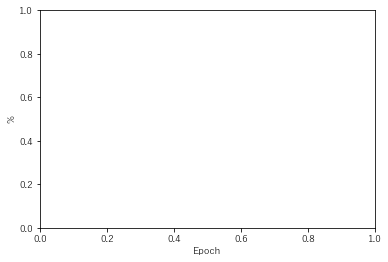

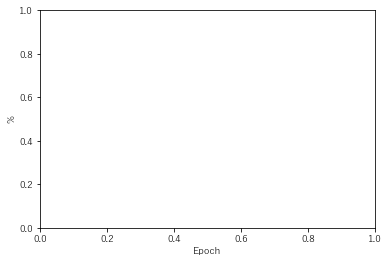

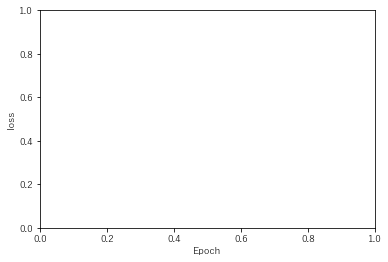

<Figure size 432x288 with 0 Axes>

In [10]:
# 生成走勢圖
df_1 = pd.DataFrame({"train_epoch": data[0], "Recall@20": data[1], "MRR@20": data[2], "NDCG@20": data[3]}) #訓練
df_2 = pd.DataFrame({"test_epoch": data[0], "Recall@20": data[4], "MRR@20": data[5], "NDCG@20": data[6]}) #測試
df_3 = pd.DataFrame({"loss_epoch": data[0], "train_loss": data[7], "test_loss": data[8]})
png("train_epoch", "Recall@20", "MRR@20", "NDCG@20", dataset+"-"+log_file_name+"-k@20評估指標走勢圖_train", "k@20評估指標走勢圖_train")#訓練
png("test_epoch", "Recall@20", "MRR@20", "NDCG@20", dataset+"-"+log_file_name+"-k@20評估指標走勢圖_test", "k@20評估指標走勢圖_test")  #測試
png("loss_epoch", "train_loss", "test_loss", "none", dataset+"-"+log_file_name+"-loss走勢圖", "loss走勢圖")